# QFAN training — user-defined function

Trains **QFAN** on samples of a function you define — same workflow as notebook **03** (loss curve, prediction plot, learned basis profiles, Mode A encode/reconstruct check), but instead of a Feynman equation ID you supply a Python **`target_y`**.

- Inputs are drawn uniformly in **$[-1,1]^{d}$** (`input_dim`).
- Targets are **scalar** $y = \texttt{target\_y}(x)$.
- Training minimizes MSE with Adam (`train_qfan`), matching the 03 hyperparameter style (`num_functions`, `n_qubits`, `mode`, `steps`, `lr`).
- During training, set **`log_every`** to `1` or `5` to print **live** MSE each epoch (or every 5 epochs). Optionally set **`live_plot_every`** to refresh loss (and 1D fit) plots in the notebook each N epochs (`None` = static plots only after training).
- Set **`snapshot_every`** (e.g. `5`) to save the 1D QFAN curve on the dense grid that often for section **2b** (plus random init and the final epoch).
- Section **2b** plots loss with snapshot markers and, for `input_dim == 1`, how the QFAN curve evolves on a dense grid during training.

In [22]:
import sys
from pathlib import Path

# Repo root (works if cwd is notebooks/ or QFun/)
for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "qfun").is_dir():
        _root = str(_p.resolve())
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break

import numpy as np
import matplotlib.pyplot as plt
import pennylane.numpy as pnp

from qfun.qfan import (
    QFANBlock,
    QFANConfig,
    mode_a_signed_encode,
    reconstruct_mode_a_signed,
    train_qfan,
)

## 1. Target function and hyperparameters

Implement **`target_y(x)`** with `x` of shape `(n_samples, input_dim)` and return shape `(n_samples,)`. For `input_dim > 1`, combine columns inside `target_y` (e.g. `np.sum(x * x, axis=1)`).

In [ ]:
def target_y(x: np.ndarray) -> np.ndarray:
    """Scalar targets for each row of x (shape (n, input_dim))."""
    t = x[:, 0]
    return np.exp(t) + np.cos(t) + np.sqrt(t**2)


input_dim = 1
n_samples = 512
test_split = 0.2
data_seed = 0
num_functions = 3
n_qubits = 5
mode = "mode_a"
steps = 150
lr = 0.05
model_seed = 42

# Live progress: each Adam step = one full pass over x_train (one "epoch").
log_every = 5  # print train MSE every N epochs; use 1 for every epoch; None to disable
live_plot_every = None  # e.g. 5 or 1 to refresh plots in-notebook each N epochs; None = off

## 2. Sample data and train/test split

Same split pattern as `train_feynman_equation` / notebook 03.

In [ ]:
rng = np.random.default_rng(data_seed)
x_all = rng.uniform(-1.0, 1.0, size=(n_samples, input_dim))
y_all = np.asarray(target_y(x_all), dtype=float)
if y_all.ndim != 1 or y_all.shape[0] != n_samples:
    raise ValueError("target_y must return shape (n_samples,)")

split = int((1.0 - test_split) * len(y_all))
split = max(1, min(split, len(y_all) - 1))
x_train, x_test = x_all[:split], x_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

cfg = QFANConfig(
    input_dim=input_dim,
    num_functions=num_functions,
    n_qubits=n_qubits,
    mode=mode,
    learning_rate=lr,
    steps=steps,
    seed=model_seed,
)

# Snapshots: step -1 = random init; then after each Adam step
x_snap = np.linspace(-1.0, 1.0, 256).reshape(-1, 1) if input_dim == 1 else None
snapshot_interval = max(1, steps // 10)
training_snapshots: list[tuple[int, float]] = []
training_curve_snapshots: list[tuple[int, float, np.ndarray]] = []
live_mse_so_far: list[float] = []


def _maybe_live_plot(step: int, m: QFANBlock) -> None:
    if live_plot_every is None or step < 0:
        return
    if step % live_plot_every != 0 and step != steps - 1:
        return
    try:
        from IPython.display import clear_output

        clear_output(wait=True)
    except Exception:
        return
    if not live_mse_so_far:
        return
    if input_dim == 1 and x_snap is not None:
        fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3))
        ax0.plot(live_mse_so_far)
        ax0.set_title("Train MSE (live)")
        ax0.set_xlabel("epoch")
        ax0.set_ylabel("MSE")
        y_line = np.asarray(m.forward_batch(pnp.array(x_snap)))
        xs = x_snap[:, 0]
        ax1.plot(xs, target_y(x_snap), "k--", lw=2, label="target")
        ax1.plot(xs, y_line, lw=2, label="QFAN")
        ax1.set_xlabel("x")
        ax1.set_ylabel("y")
        ax1.legend(loc="best")
        ax1.set_title(f"epoch {step + 1}")
    else:
        fig, ax0 = plt.subplots(figsize=(6, 3))
        ax0.plot(live_mse_so_far)
        ax0.set_title("Train MSE (live)")
        ax0.set_xlabel("epoch")
        ax0.set_ylabel("MSE")
    plt.tight_layout()
    plt.show()


def after_step(step: int, loss: float, m: QFANBlock) -> None:
    training_snapshots.append((step, loss))
    if step >= 0:
        live_mse_so_far.append(loss)
    if x_snap is not None and (
        step == -1 or step % snapshot_interval == 0 or step == steps - 1
    ):
        y_line = np.asarray(m.forward_batch(pnp.array(x_snap)))
        training_curve_snapshots.append((step, loss, y_line))
    _maybe_live_plot(step, m)


model, losses = train_qfan(
    x_train, y_train, cfg, after_step=after_step, log_every=log_every
)

pred_train = np.asarray(model.forward_batch(x_train))
pred_test = np.asarray(model.forward_batch(x_test))
train_mse = float(np.mean((pred_train - y_train) ** 2))
test_mse = float(np.mean((pred_test - y_test) ** 2))
print(f"train_MSE={train_mse:.6f}  test_MSE={test_mse:.6f}")
losses[0], losses[-1]

Training 150 epochs (logging every 5)…
  epoch 5/150  train_mse=7.154586
  epoch 10/150  train_mse=6.727239
  epoch 15/150  train_mse=5.844390
  epoch 20/150  train_mse=4.073326
  epoch 25/150  train_mse=2.328082
  epoch 30/150  train_mse=1.090749
  epoch 35/150  train_mse=0.724159
  epoch 40/150  train_mse=0.208361
  epoch 45/150  train_mse=0.168375
  epoch 50/150  train_mse=0.046951
  epoch 55/150  train_mse=0.016221
  epoch 60/150  train_mse=0.016999
  epoch 65/150  train_mse=0.011378
  epoch 70/150  train_mse=0.005029
  epoch 75/150  train_mse=0.002102
  epoch 80/150  train_mse=0.000701
  epoch 85/150  train_mse=0.000934
  epoch 90/150  train_mse=0.001161
  epoch 95/150  train_mse=0.000658
  epoch 100/150  train_mse=0.000468
  epoch 105/150  train_mse=0.000407
  epoch 110/150  train_mse=0.000491
  epoch 115/150  train_mse=0.000552
  epoch 120/150  train_mse=0.000482
  epoch 125/150  train_mse=0.000569
  epoch 130/150  train_mse=0.008882
  epoch 135/150  train_mse=0.001448
  epoch 1

(np.float64(7.3148971596981145), np.float64(0.0012354173733956735))

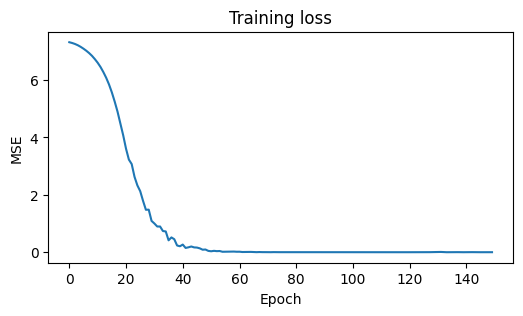

In [25]:
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

## 2b. Training process (snapshots)

The training cell records a few checkpoints. Below: loss with snapshot markers, a small step–MSE table, and (when `input_dim == 1`) how the learned curve moves toward the target.

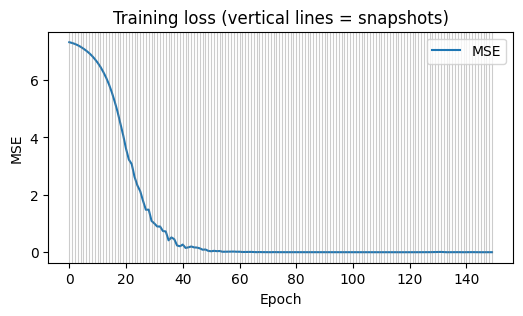

Epoch | MSE at snapshot
   -1 | 7.3149
   17 | 4.8981
   35 | 0.415126
   53 | 0.0425427
   71 | 0.00142076
   89 | 0.00116079
  107 | 0.000706013
  125 | 0.000767731
  143 | 0.00149964


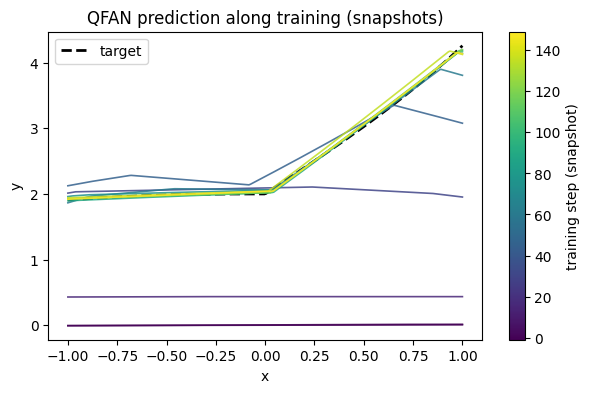

In [ ]:
if training_snapshots:
    plt.figure(figsize=(6, 3))
    plt.plot(losses, label="MSE")
    if training_curve_snapshots:
        for s, _, _ in training_curve_snapshots:
            if s >= 0:
                plt.axvline(s, color="gray", alpha=0.4, linewidth=0.8)
    else:
        for s, _ in training_snapshots:
            if s >= 0 and (s % snapshot_interval == 0 or s == steps - 1):
                plt.axvline(s, color="gray", alpha=0.4, linewidth=0.8)
    plt.title("Training loss (vertical lines = curve snapshots)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

    subsample = training_snapshots[:: max(1, len(training_snapshots) // 8)]
    print("Epoch | MSE at snapshot")
    for s, mse in subsample:
        print(f"{s:5d} | {mse:.6g}")
else:
    print("No snapshots recorded (rerun the training cell).")

if input_dim == 1 and x_snap is not None and training_curve_snapshots:
    fig, ax = plt.subplots(figsize=(7, 4))
    y_true = target_y(x_snap)
    ax.plot(x_snap, y_true, "k--", linewidth=2, label="target")
    cmap = plt.cm.viridis
    steps_list = [s for s, _, _ in training_curve_snapshots]
    smin, smax = min(steps_list), max(steps_list)
    for s, _mse, y_hat in training_curve_snapshots:
        t = 0.0 if smax == smin else (s - smin) / (smax - smin)
        ax.plot(x_snap, y_hat, color=cmap(t), alpha=0.85, linewidth=1.2)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=smin, vmax=smax))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="training step (snapshot)")
    ax.set_title("QFAN prediction along training (snapshots)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="best")
    plt.show()
elif input_dim > 1:
    print("Curve snapshots are only shown when input_dim == 1.")

## 3. Predictions vs ground truth

1D: dense grid in $[-1,1]$ plus train/test scatter. Multi-D: parity plot.

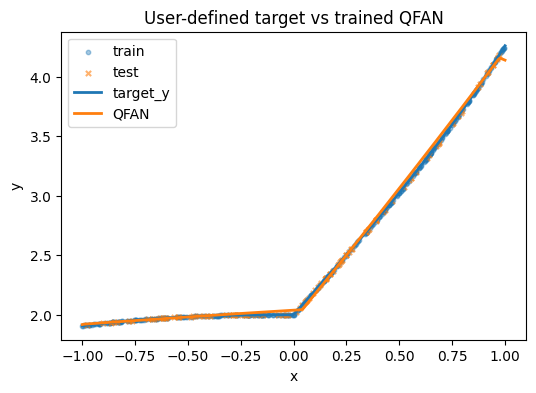

In [27]:
if input_dim == 1:
    x_line = np.linspace(-1.0, 1.0, 256).reshape(-1, 1)
    y_true = np.asarray(target_y(x_line))
    y_pred = np.asarray(model.forward_batch(pnp.array(x_line)))
    plt.figure(figsize=(6, 4))
    plt.scatter(x_train[:, 0], y_train, s=10, alpha=0.4, label="train")
    plt.scatter(x_test[:, 0], y_test, s=14, alpha=0.6, label="test", marker="x")
    plt.plot(x_line[:, 0], y_true, label="target_y", lw=2)
    plt.plot(x_line[:, 0], y_pred, label="QFAN", lw=2)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.title("User-defined target vs trained QFAN")
    plt.show()
else:
    plt.figure(figsize=(5, 5))
    plt.scatter(y_train, pred_train, s=8, alpha=0.5, label="train")
    plt.scatter(y_test, pred_test, s=12, alpha=0.7, label="test", marker="x")
    lo = min(float(y_train.min()), float(y_test.min()))
    hi = max(float(y_train.max()), float(y_test.max()))
    plt.plot([lo, hi], [lo, hi], "k--", lw=1)
    plt.xlabel("y true")
    plt.ylabel("y pred")
    plt.legend()
    plt.title(f"Parity plot ({input_dim} inputs)")
    plt.show()

## 4. Learned basis profiles

Same as notebook 03: one subplot per basis index $m$.

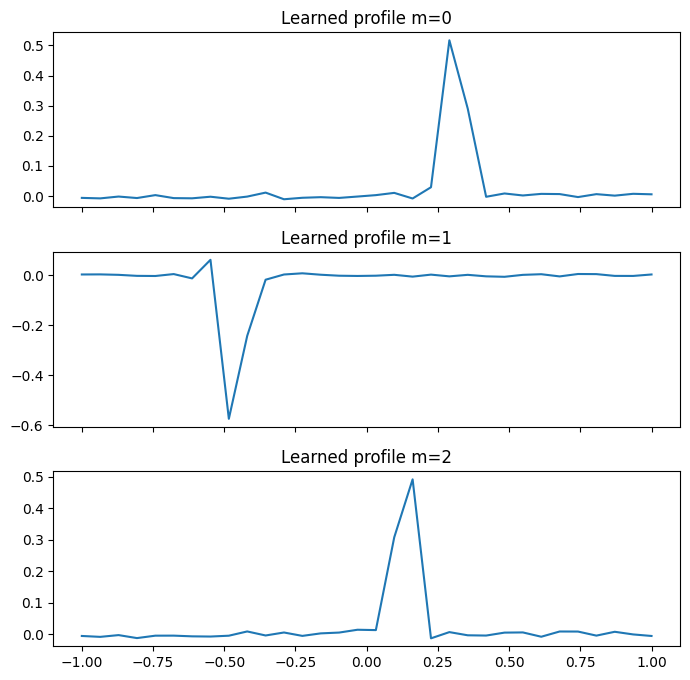

In [28]:
fig, axes = plt.subplots(
    model.num_functions, 1, figsize=(7, 2.3 * model.num_functions), sharex=True
)
if model.num_functions == 1:
    axes = [axes]
for m in range(model.num_functions):
    axes[m].plot(np.asarray(model.x_grid), np.asarray(model.get_profile(m)))
    axes[m].set_title(f"Learned profile m={m}")
plt.tight_layout()
plt.show()

## 5. Mode A sanity check (signed profile)

For `mode == "mode_a"`, reconstruction matches $f / \sum|f|$ on the grid (see notebook 03).

max |reconstruction - f/sum|f|| = 2.84e-12


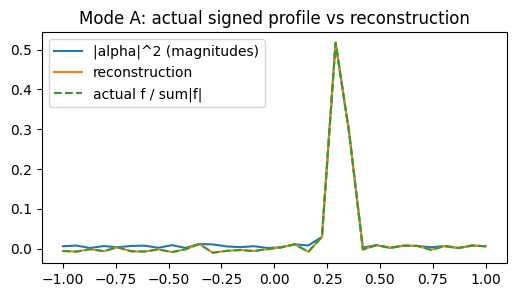

In [ ]:
if mode != "mode_a":
    print("Skipping: encode/reconstruct demo is for mode_a.")
else:
    m = 0
    grid_vals = np.asarray(model.grid_values[m])
    alpha, sign_bits = mode_a_signed_encode(grid_vals)
    q_hat = reconstruct_mode_a_signed(alpha, sign_bits)

    l1 = np.sum(np.abs(grid_vals)) + 1e-12
    f_normalized = grid_vals / l1
    max_abs_err = float(np.max(np.abs(q_hat - f_normalized)))
    print(f"max |reconstruction - f/sum|f|| = {max_abs_err:.2e}")

    plt.figure(figsize=(6, 3))
    plt.plot(np.asarray(model.x_grid), np.abs(alpha) ** 2, label="|alpha|^2 (magnitudes)")
    plt.plot(np.asarray(model.x_grid), q_hat, label="reconstruction")
    plt.plot(np.asarray(model.x_grid), f_normalized, "--", label="actual f / sum|f|")
    plt.legend()
    plt.title("Mode A: actual signed profile vs reconstruction")
    plt.show()